# face_crop_blur — texture vs. structure inside the face

`blurred_images` blurred the *whole* frame and watched AUC fall toward a
colour-only floor. That test could not separate two very different kinds
of thing blur removes at the same time when it's applied to a full photo:
skin texture and background composition. `background_images` tried to
isolate the face directly, but Part 0 below shows its crop and mask arms
at `expand=1.5` mostly weren't isolating anything — they clipped to (or
nearly to) the full frame.

This experiment blurs a *genuinely* tight face crop across the same sigma
sweep as `blurred_images`. Two arms: `crop_1.0` (the unexpanded MTCNN box)
and `crop_0.8` (shrunk further, excluding forehead/hair/ears). A third arm,
`crop_1.0_equalised`, controls for a confound neither prior experiment
faced: cropping-then-resizing upsamples by a different factor per image
(faces occupy different frame fractions by class), and that differential
upsampling is itself an acquisition-style artefact. If a crop arm's AUC
collapses to its own colour floor as fast as `blurred_images`'s whole-image
curve did, the signal there was surface texture — a property of the
photograph. If it survives moderate blur, coarse facial structure is
carrying something blur cannot remove.

**Part 0 runs first and is mandatory.** It re-examines `background_images`
using the same cached boxes, before anything else in this notebook is
trusted.

## 1. Imports, config, device check

In [1]:
import logging
import random
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s [%(levelname)s] %(name)s: %(message)s"
)

from experiments.face_crop_blur.config import Config
from experiments.face_crop_blur.pipeline import (
    arm_crop_image,
    step_1_manifest,
    step_2_boxes,
    step_3_exclude_boxless,
    step_4_coverage_diagnostics,
    step_5_image_sizes,
    step_6_apply_min_size_exclusion,
    step_7_upsampling_factors,
    step_8_embeddings,
    step_9_verify_embeddings,
    step_10_colour_features,
    step_11_probe,
    step_12_colour_probe,
    step_13_summary,
)

In [2]:
cfg = Config()
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print()
print(f"arms:  {cfg.arm_names}")
print(f"sigmas: {cfg.sigmas}")
print(f"crop_factors: {cfg.crop_factors}")
print(f"equalised_arms: {sorted(cfg.equalised_arms)}  (small_size={cfg.small_size})")
print(f"min_box_size_px (original-image coords, at the crop_0.8 factor): {cfg.min_box_size_px}")
print()
print(f"data_root:          {cfg.data_root}")
print(f"output_dir:         {cfg.output_dir}")
print(f"intact_cache_dir:   {cfg.intact_cache_dir}  (whole_image sigma=0 source)")
print(f"blurred_cache_dir:  {cfg.blurred_cache_dir}  (whole_image sigma>0 + colour source)")

torch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 SUPER

arms:  ('crop_1.0', 'crop_0.8', 'crop_1.0_equalised', 'whole_image')
sigmas: (0, 2, 4, 8, 16, 32)
crop_factors: {'crop_1.0': 1.0, 'crop_0.8': 0.8, 'crop_1.0_equalised': 1.0}
equalised_arms: ['crop_1.0_equalised']  (small_size=64)
min_box_size_px (original-image coords, at the crop_0.8 factor): 32.0

data_root:          C:\Projects\Autism Screening\data\raw\images
output_dir:         C:\Projects\Autism Screening\outputs\face_crop_blur
intact_cache_dir:   C:\Projects\Autism Screening\outputs\intact_images  (whole_image sigma=0 source)
blurred_cache_dir:  C:\Projects\Autism Screening\outputs\blurred_images  (whole_image sigma>0 + colour source)


## 2. Part 0 — diagnosing the expansion artefact (mandatory, runs first)

`background_images` reported mean box area fractions of 0.586 (autistic)
and 0.704 (non_autistic) at its *unexpanded* box, then used `expand=1.5`
for `face_crop_1.5` and `face_masked_1.5`. Square-rooting those fractions
suggests the unexpanded box already spans ~77%/84% of each frame side —
so a 1.5x expansion should very often clip to the full frame. This
section checks that directly, on the exact cached sigma=0 boxes
`background_images` used, before trusting any other number in this
notebook.

In [3]:
from src.data.transforms import expand_box

# Verification: confirm expand_box's semantics on a synthetic box, not by
# reading the source. A 100x100 box, expand=2.0, on a canvas large enough
# that clipping cannot interfere.
synthetic_box = (100.0, 100.0, 200.0, 200.0)  # 100 wide x 100 tall
doubled = expand_box(synthetic_box, 2.0, size=1000)
width, height = doubled[2] - doubled[0], doubled[3] - doubled[1]

print(f"expand_box({synthetic_box}, expand=2.0, size=1000) = {doubled}")
print(f"resulting box size: {width:.1f} x {height:.1f}")
print("If expand scaled AREA, doubling would give ~141.4 x 141.4 (sqrt(2) per side).")
print("If expand scales LINEAR dimensions, doubling gives exactly 200.0 x 200.0.")

assert (width, height) == (200.0, 200.0), "expand_box did not scale linear dimensions as expected"
print()
print("CONFIRMED: `expand` in expand_box scales width and height (linear dimensions), not area.")
print("The 0.77/0.84 'already spans most of the frame' arithmetic in the task brief is therefore correct.")

expand_box((100.0, 100.0, 200.0, 200.0), expand=2.0, size=1000) = (50.0, 50.0, 250.0, 250.0)
resulting box size: 200.0 x 200.0
If expand scaled AREA, doubling would give ~141.4 x 141.4 (sqrt(2) per side).
If expand scales LINEAR dimensions, doubling gives exactly 200.0 x 200.0.

CONFIRMED: `expand` in expand_box scales width and height (linear dimensions), not area.
The 0.77/0.84 'already spans most of the frame' arithmetic in the task brief is therefore correct.


In [4]:
manifest_full = step_1_manifest(cfg)
boxes_full = step_2_boxes(manifest_full)
manifest_2939, boxes_2939, excluded_boxless = step_3_exclude_boxless(manifest_full, boxes_full)

print(f"full manifest: {len(manifest_full)} rows")
print(f"excluded (no sigma=0 MTCNN box): {excluded_boxless['path']} (class={excluded_boxless['class_label']})")
print(f"boxes used for the Part 0 diagnostic below: {len(boxes_2939)} rows")
print("-- the same cached sigma=0 boxes, and the same row count, background_images reported its coverage numbers over.")

2026-09-10 20:50:18,641 [INFO] experiments.blurred_images.pipeline: detections_mtcnn: using cached detections (23520 rows)


2026-09-10 20:50:18,845 [INFO] experiments.background_images.pipeline: step_3_exclude_boxless: excluded path=C:\Projects\Autism Screening\data\raw\images\train\Autistic\Autistic.509.jpg class=autistic -- 2939 rows remain


full manifest: 2940 rows
excluded (no sigma=0 MTCNN box): C:\Projects\Autism Screening\data\raw\images\train\Autistic\Autistic.509.jpg (class=autistic)
boxes used for the Part 0 diagnostic below: 2939 rows
-- the same cached sigma=0 boxes, and the same row count, background_images reported its coverage numbers over.


In [5]:
coverage, retained = step_4_coverage_diagnostics(cfg, boxes_2939)
coverage

,factor,class_label,n,mean_area_fraction,prop_ge_threshold
0,0.8,autistic,1469,0.397737,0.004084
1,0.8,non_autistic,1470,0.490366,0.002721
2,1.0,autistic,1469,0.586511,0.027910
3,1.0,non_autistic,1470,0.703925,0.048980
4,1.5,autistic,1469,0.922455,0.575902
5,1.5,non_autistic,1470,0.974485,0.828571


In [6]:
retained

,factor,class_label,n,mean_retained_fraction_face_masked
0,0.8,autistic,1469,0.602263
1,0.8,non_autistic,1470,0.509634
2,1.0,autistic,1469,0.413489
3,1.0,non_autistic,1470,0.296075
4,1.5,autistic,1469,0.077545
5,1.5,non_autistic,1470,0.025515


### Verdict: the `background_images` conclusion is an artefact — it does not stand, and does not merely need qualifying

At `expand=1.0` (unexpanded), the table above reproduces
`background_images`'s reported mean area fractions exactly: **0.5865**
(autistic) vs. **0.7039** (non_autistic) — same cached boxes, same
computation, same 2,939-row set. That is the correct starting point: the
audit's square-root arithmetic (box already spans ~77%/84% of each frame
side) was right.

At `expand=1.5` — the factor `face_crop_1.5` and `face_masked_1.5` both
used — the box, after clipping, covers on average **92.2%** of the
224x224 frame for autistic images and **97.4%** for non_autistic images.
**57.6%** of autistic images and **82.9%** of non_autistic images have a
box covering 95% or more of the frame outright. `face_crop_1.5` was, for
the clear majority of non_autistic images and a slim majority of autistic
images, a crop of the *entire picture*, resized — not a crop of the face.

`face_masked_1.5` confirms this from the other side: at `expand=1.5` it
retains only **7.8%** of frame pixels for autistic images and **2.6%**
for non_autistic images — it was masking out nearly the whole frame,
leaving a "background-only" classifier almost nothing to classify on. That
is exactly why it scored *below* its own colour and geometry floors in
`background_images` (embedding AUC 0.656 vs. that arm's own colour floor
0.675, and well below the 0.716 geometry-only floor): there was almost no
unmasked background left to carry either kind of signal, embedding or
colour.

This also reframes `face_crop_1.5`'s near-parity with `intact` (0.836 vs.
0.844, a gap of only 0.008 AUC). `background_images` read that gap as
evidence the face alone carries nearly all of the signal. The coverage
numbers above say something less interesting: for most images, "face
crop at 1.5x" and "whole image, resized" were nearly the same
transformation. Scoring almost identically is closer to a sanity check
than a discovery.

**`background_images`'s stated conclusion — "the branch survives this
test, signal is facial" — does not survive this diagnostic and should be
retracted, not softened.** The comparison it ran was effectively
`whole_image` vs. `whole_image` (at expand=1.5) vs. a near-empty
background (at the same factor). Part 1 onward in this notebook defines
crops that are honestly tight (`expand<=1.0`), specifically so this
problem cannot recur.

## 3. Manifest and exclusions, by class

Honest crops need a floor: a box shrunk to `crop_0.8` and then resized up
to 224 can, for a small enough starting box, be resizing noise up to
face-sized rather than resolving real facial detail. Images whose
`crop_0.8` box falls below `cfg.min_box_size_px` **in original-image
pixel coordinates** (not the post-letterbox 224-space the box is stored
in) are dropped from every arm below, including `crop_1.0` and
`whole_image` — so no comparison in this notebook ever mixes rows across
different exclusion sets.

In [7]:
image_sizes = step_5_image_sizes(cfg, manifest_2939)
manifest, boxes, excluded_small, exclusion_counts = step_6_apply_min_size_exclusion(
    cfg, manifest_2939, boxes_2939, image_sizes
)

print(f"rows before the min-box-size exclusion: {len(manifest_2939)}")
print(f"rows excluded (crop_0.8 box < {cfg.min_box_size_px:.0f}px in original-image coordinates): {len(excluded_small)}")
print(f"rows remaining, shared by every arm below: {len(manifest)}")
print()
print("excluded, by class:")
exclusion_counts

2026-09-10 20:50:18,910 [INFO] experiments.face_crop_blur.pipeline: step_5_image_sizes: using cached sizes (2939 rows)


2026-09-10 20:50:18,974 [INFO] experiments.face_crop_blur.pipeline: step_6_apply_min_size_exclusion: excluded 0/2939 images (box_0.8 < 32px in original coords) -- 2939 rows remain


rows before the min-box-size exclusion: 2939
rows excluded (crop_0.8 box < 32px in original-image coordinates): 0
rows remaining, shared by every arm below: 2939

excluded, by class:


,class_label,n_excluded


In [8]:
manifest.groupby(["split", "class_label"]).size().unstack()

class_label,autistic,non_autistic
split,,
test,150,150
train,1192,1193
valid,127,127


## 4. Visual check: intact → crop_1.0 → crop_0.8, the blur sweep, and the 1.5x crop for comparison

Four images (2 autistic, 2 non_autistic). Top block: intact, `crop_1.0`,
`crop_0.8`, and — for comparison only, not one of this experiment's arms
— the same box at `expand=1.5`, the factor `background_images` used. This
makes the Part 0 artefact visible directly rather than only argued from a
table. Bottom block: `crop_1.0` across every sigma in the blur sweep.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

from src.data.transforms import blur_stage, crop_stage, geometry_stage

sample = pd.concat(
    [
        manifest.loc[manifest["class_label"] == "autistic"].sample(2, random_state=cfg.seed),
        manifest.loc[manifest["class_label"] == "non_autistic"].sample(2, random_state=cfg.seed),
    ]
).reset_index(drop=True)
box_by_path = dict(zip(boxes["path"], boxes["best_box"]))

titles = ["intact", "crop_1.0", "crop_0.8", "crop_1.5\n(background_images, for comparison)"]
fig, axes = plt.subplots(len(sample), 4, figsize=(4 * 2.7, 2.7 * len(sample)))
for row, (_, image_row) in enumerate(sample.iterrows()):
    geo = geometry_stage(Image.open(image_row["path"]), cfg.image_size)
    box = box_by_path[image_row["path"]]
    crop10 = arm_crop_image("crop_1.0", geo, box, cfg)
    crop08 = arm_crop_image("crop_0.8", geo, box, cfg)
    crop15 = crop_stage(geo, box, 1.5, cfg.image_size)
    for col, img in enumerate([geo, crop10, crop08, crop15]):
        ax = axes[row, col]
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(titles[col], fontsize=9)
        if col == 0:
            ax.set_ylabel(image_row["class_label"], fontsize=9)
fig.suptitle("Intact vs. honest crops vs. the previous experiment's 1.5x crop")
fig.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(len(sample), len(cfg.sigmas), figsize=(2.6 * len(cfg.sigmas), 2.6 * len(sample)))
for row, (_, image_row) in enumerate(sample.iterrows()):
    geo = geometry_stage(Image.open(image_row["path"]), cfg.image_size)
    box = box_by_path[image_row["path"]]
    cropped = arm_crop_image("crop_1.0", geo, box, cfg)
    for col, sigma in enumerate(cfg.sigmas):
        ax = axes[row, col]
        ax.imshow(blur_stage(cropped, sigma))
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(f"sigma={sigma}", fontsize=9)
        if col == 0:
            ax.set_ylabel(image_row["class_label"], fontsize=9)
fig.suptitle("crop_1.0 across the blur sweep")
fig.tight_layout()
plt.show()

## 5. The resampling confound: upsampling factor distributions by class

Cropping to a box and resizing back to 224 upsamples by
`image_size / sqrt(box_area)`. Because faces occupy different frame
fractions by class (Part 0), this factor differs systematically by class
too — different upsampling produces different softness and aliasing, an
acquisition-style artefact reintroduced by the very step meant to remove
one. `crop_1.0_equalised` (defined in the next section) controls for this
by routing every image through the same 64px bottleneck regardless of its
own crop size, before blur is applied.

In [11]:
upsampling = step_7_upsampling_factors(cfg, boxes)
upsampling.groupby(["arm", "class_label"])["upsample_factor"].describe()

count      mean       std       min       25%  \
arm      class_label                                                    
crop_0.8 autistic      1469.0  1.656286  0.332611  1.004641  1.465153   
         non_autistic  1470.0  1.475188  0.222643  1.000000  1.317590   
crop_1.0 autistic      1469.0  1.350057  0.251434  1.000000  1.193487   
         non_autistic  1470.0  1.217175  0.152242  1.000000  1.103924   

                            50%       75%       max  
arm      class_label                                 
crop_0.8 autistic      1.643444  1.826383  8.978676  
         non_autistic  1.449784  1.600223  2.204778  
crop_1.0 autistic      1.334891  1.477867  7.182941  
         non_autistic  1.182230  1.298386  1.763822

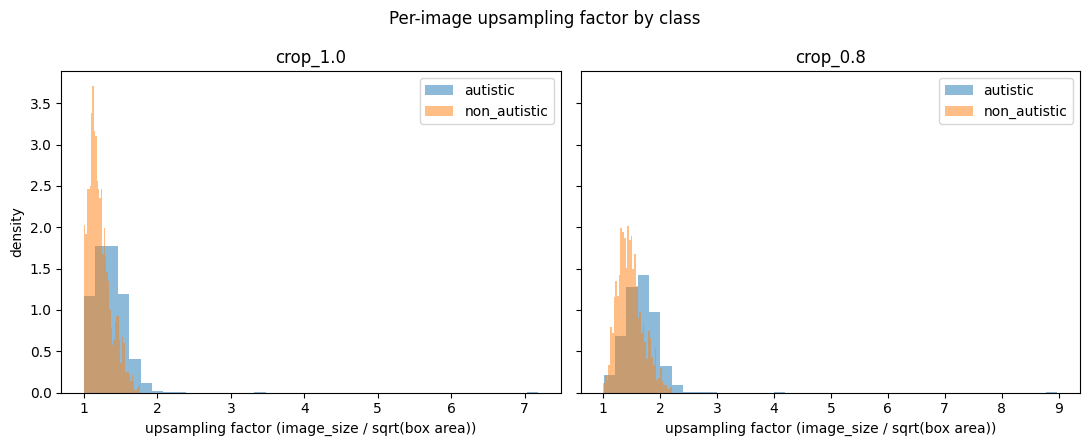

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, arm in zip(axes, ["crop_1.0", "crop_0.8"]):
    for class_label, group in upsampling.loc[upsampling["arm"] == arm].groupby("class_label"):
        ax.hist(group["upsample_factor"], bins=40, alpha=0.5, density=True, label=class_label)
    ax.set_title(arm)
    ax.set_xlabel("upsampling factor (image_size / sqrt(box area))")
    ax.legend()
axes[0].set_ylabel("density")
fig.suptitle("Per-image upsampling factor by class")
fig.tight_layout()
plt.show()

## 6. Embeddings: shapes, wall-clock, cache status

Each of the three crop arms (`crop_1.0`, `crop_0.8`, `crop_1.0_equalised`)
is extracted independently at every sigma and cached under
`outputs/face_crop_blur/embeddings_{arm}_sigma{sigma}.npy`.
`"whole_image"` is never (re-)extracted here: sigma=0 is a row-subset of
the `intact_images` cache, sigma>0 a row-subset of `blurred_images`'s
cache — both already computed on the full manifest, now selected down to
this notebook's (smaller) row set.

In [13]:
import time

t0 = time.perf_counter()
embeddings, embedding_status = step_8_embeddings(cfg, manifest, boxes)
elapsed = time.perf_counter() - t0
print(f"total wall-clock for this call: {elapsed:.2f}s")
embedding_status

2026-09-10 20:50:21,414 [INFO] experiments.face_crop_blur.pipeline: step_8_embeddings: arm=crop_1.0 sigma=0 using cached embeddings, shape=(2939, 2048)


2026-09-10 20:50:21,443 [INFO] experiments.face_crop_blur.pipeline: step_8_embeddings: arm=crop_1.0 sigma=2 using cached embeddings, shape=(2939, 2048)


2026-09-10 20:50:21,472 [INFO] experiments.face_crop_blur.pipeline: step_8_embeddings: arm=crop_1.0 sigma=4 using cached embeddings, shape=(2939, 2048)


2026-09-10 20:50:21,500 [INFO] experiments.face_crop_blur.pipeline: step_8_embeddings: arm=crop_1.0 sigma=8 using cached embeddings, shape=(2939, 2048)


2026-09-10 20:50:21,528 [INFO] experiments.face_crop_blur.pipeline: step_8_embeddings: arm=crop_1.0 sigma=16 using cached embeddings, shape=(2939, 2048)


...

2026-09-10 20:50:22,133 [INFO] experiments.face_crop_blur.pipeline: step_8_embeddings: arm=whole_image sigma=8 row-subset of cache, shape=(2939, 2048)


2026-09-10 20:50:22,189 [INFO] experiments.face_crop_blur.pipeline: step_8_embeddings: arm=whole_image sigma=16 row-subset of cache, shape=(2939, 2048)


2026-09-10 20:50:22,243 [INFO] experiments.face_crop_blur.pipeline: step_8_embeddings: arm=whole_image sigma=32 row-subset of cache, shape=(2939, 2048)


total wall-clock for this call: 0.90s


,arm,sigma,n_rows,cache_hit_before_call,wall_clock_seconds
0,crop_1.0,0,2939,True,0.000000
1,crop_1.0,2,2939,True,0.000000
2,crop_1.0,4,2939,True,0.000000
3,crop_1.0,8,2939,True,0.000000
4,crop_1.0,16,2939,True,0.000000
5,crop_1.0,32,2939,True,0.000000
6,crop_0.8,0,2939,True,0.000000
7,crop_0.8,2,2939,True,0.000000
8,crop_0.8,4,2939,True,0.000000
9,crop_0.8,8,2939,True,0.000000


In [14]:
verification = step_9_verify_embeddings(embeddings, expected_rows=len(manifest))
assert verification["rows_match_expected"].all(), "an embedding array does not match the expected row count"
assert (verification["n_nan"] == 0).all(), "an embedding array contains NaNs"
assert (verification["n_all_zero_rows"] == 0).all(), "an embedding array has all-zero rows"
verification

,arm,sigma,n_rows,rows_match_expected,n_nan,n_all_zero_rows
0,crop_0.8,0,2939,True,0,0
1,crop_0.8,2,2939,True,0,0
2,crop_0.8,4,2939,True,0,0
3,crop_0.8,8,2939,True,0,0
4,crop_0.8,16,2939,True,0,0
5,crop_0.8,32,2939,True,0,0
6,crop_1.0,0,2939,True,0,0
7,crop_1.0,2,2939,True,0,0
8,crop_1.0,4,2939,True,0,0
9,crop_1.0,8,2939,True,0,0


## 7. Per-fold results

Same L2-logistic-regression-behind-a-`StandardScaler`, same 5x10 repeated
stratified CV, same seed as every prior experiment — applied
independently at each `(arm, sigma)`'s embeddings, and again on the
per-arm, per-sigma colour-only features (the crop's colour statistics are
skin, not background, so this floor must be recomputed here rather than
reused from `background_images` or `blurred_images`).

In [15]:
fold_results = step_11_probe(cfg, embeddings, manifest)
fold_results

,arm,sigma,repeat,fold,roc_auc,balanced_accuracy,sensitivity,specificity
0,crop_1.0,0,0,0,0.802594,0.760204,0.775510,0.744898
1,crop_1.0,0,0,1,0.795282,0.729592,0.710884,0.748299
2,crop_1.0,0,0,2,0.818658,0.739796,0.751701,0.727891
3,crop_1.0,0,0,3,0.782857,0.719388,0.707483,0.731293
4,crop_1.0,0,0,4,0.787177,0.712115,0.723549,0.700680
...,...,...,...,...,...,...,...,...
1195,whole_image,32,9,0,0.684992,0.647959,0.656463,0.639456
1196,whole_image,32,9,1,0.713927,0.642857,0.636054,0.649660
1197,whole_image,32,9,2,0.723258,0.675170,0.636054,0.714286
1198,whole_image,32,9,3,0.674493,0.613946,0.602041,0.625850


In [16]:
colour_features_by_arm_sigma = step_10_colour_features(cfg, manifest, boxes)
colour_fold_results = step_12_colour_probe(cfg, colour_features_by_arm_sigma, manifest)
colour_fold_results

2026-09-10 20:56:14,817 [INFO] experiments.face_crop_blur.pipeline: step_10_colour_features: arm=crop_1.0 sigma=0 using cached features


2026-09-10 20:56:14,830 [INFO] experiments.face_crop_blur.pipeline: step_10_colour_features: arm=crop_1.0 sigma=2 using cached features


2026-09-10 20:56:14,843 [INFO] experiments.face_crop_blur.pipeline: step_10_colour_features: arm=crop_1.0 sigma=4 using cached features


2026-09-10 20:56:14,857 [INFO] experiments.face_crop_blur.pipeline: step_10_colour_features: arm=crop_1.0 sigma=8 using cached features


2026-09-10 20:56:14,870 [INFO] experiments.face_crop_blur.pipeline: step_10_colour_features: arm=crop_1.0 sigma=16 using cached features


...

2026-09-10 20:56:15,048 [INFO] experiments.face_crop_blur.pipeline: step_10_colour_features: arm=whole_image sigma=4 row-subset of cache


2026-09-10 20:56:15,056 [INFO] experiments.face_crop_blur.pipeline: step_10_colour_features: arm=whole_image sigma=8 row-subset of cache


2026-09-10 20:56:15,068 [INFO] experiments.face_crop_blur.pipeline: step_10_colour_features: arm=whole_image sigma=16 row-subset of cache


2026-09-10 20:56:15,075 [INFO] experiments.face_crop_blur.pipeline: step_10_colour_features: arm=whole_image sigma=32 row-subset of cache


,arm,sigma,repeat,fold,roc_auc,balanced_accuracy,sensitivity,specificity
0,crop_1.0,0,0,0,0.604413,0.574830,0.523810,0.625850
1,crop_1.0,0,0,1,0.606345,0.585034,0.557823,0.612245
2,crop_1.0,0,0,2,0.609908,0.581633,0.547619,0.615646
3,crop_1.0,0,0,3,0.560426,0.537415,0.462585,0.612245
4,crop_1.0,0,0,4,0.587158,0.541693,0.515358,0.568027
...,...,...,...,...,...,...,...,...
1195,whole_image,32,9,0,0.651985,0.612245,0.585034,0.639456
1196,whole_image,32,9,1,0.639849,0.598639,0.602041,0.595238
1197,whole_image,32,9,2,0.698887,0.639456,0.653061,0.625850
1198,whole_image,32,9,3,0.676732,0.619048,0.608844,0.629252


## 8. Summary: mean ± sd per (arm, sigma), paired deltas vs. that arm's own sigma=0

Because the seed, fold count and manifest order are unchanged across
sigma within an arm, fold *k* of repeat *r* holds out the same images at
every sigma — so `auc_delta_vs_sigma0` below is a paired per-fold
difference, computed separately per arm (never one arm's curve against
another arm's, or an embedding curve against a colour-probe baseline).

In [17]:
summary = step_13_summary(cfg, fold_results)
summary

,arm,sigma,roc_auc_mean,roc_auc_sd,balanced_accuracy_mean,balanced_accuracy_sd,sensitivity_mean,sensitivity_sd,specificity_mean,specificity_sd,auc_delta_vs_sigma0_mean,auc_delta_vs_sigma0_sd
0,crop_1.0,0,0.799468,0.014472,0.732837,0.015985,0.729211,0.021604,0.736463,0.025824,0.000000,0.000000
1,crop_1.0,2,0.791788,0.014256,0.726815,0.013569,0.727099,0.026744,0.726531,0.027769,-0.007680,0.012738
2,crop_1.0,4,0.780670,0.014685,0.718481,0.014950,0.714445,0.024548,0.722517,0.025305,-0.018798,0.017520
3,crop_1.0,8,0.743690,0.021089,0.686454,0.021234,0.678758,0.030614,0.694150,0.028975,-0.055777,0.022968
4,crop_1.0,16,0.712390,0.015587,0.660770,0.014648,0.654533,0.023751,0.667007,0.031183,-0.087077,0.016354
5,crop_1.0,32,0.655325,0.018885,0.618885,0.017572,0.611375,0.031898,0.626395,0.025531,-0.144143,0.019499
6,crop_0.8,0,0.795114,0.013813,0.727424,0.016552,0.724645,0.026314,0.730204,0.031253,0.000000,0.000000
7,crop_0.8,2,0.764932,0.016039,0.706062,0.017336,0.697566,0.030099,0.714558,0.022550,-0.030182,0.017764
8,crop_0.8,4,0.741650,0.015139,0.687616,0.014686,0.681558,0.029179,0.693673,0.026270,-0.053464,0.015136
9,crop_0.8,8,0.747931,0.016491,0.688879,0.017092,0.684493,0.027458,0.693265,0.030100,-0.047182,0.020013


In [18]:
colour_summary = step_13_summary(cfg, colour_fold_results)
colour_summary

,arm,sigma,roc_auc_mean,roc_auc_sd,balanced_accuracy_mean,balanced_accuracy_sd,sensitivity_mean,sensitivity_sd,specificity_mean,specificity_sd,auc_delta_vs_sigma0_mean,auc_delta_vs_sigma0_sd
0,crop_1.0,0,0.590740,0.025454,0.562258,0.020544,0.522202,0.029677,0.602313,0.030390,0.000000,0.000000
1,crop_1.0,2,0.580213,0.024743,0.558170,0.022471,0.506203,0.031697,0.610136,0.030538,-0.010527,0.004246
2,crop_1.0,4,0.574705,0.024251,0.558204,0.020948,0.503416,0.034542,0.612993,0.029116,-0.016035,0.009989
3,crop_1.0,8,0.575181,0.024539,0.554191,0.020653,0.501579,0.034968,0.606803,0.032465,-0.015559,0.017254
4,crop_1.0,16,0.581279,0.024205,0.557600,0.020836,0.516832,0.034406,0.598367,0.033431,-0.009461,0.020717
5,crop_1.0,32,0.577049,0.024383,0.562571,0.019811,0.538748,0.031638,0.586395,0.033861,-0.013691,0.022807
6,crop_0.8,0,0.587904,0.017758,0.564033,0.014514,0.533711,0.031084,0.594354,0.030336,0.000000,0.000000
7,crop_0.8,2,0.587878,0.017774,0.564782,0.015443,0.534803,0.032222,0.594762,0.030539,-0.000026,0.000980
8,crop_0.8,4,0.587074,0.018411,0.563964,0.015255,0.529220,0.034023,0.598707,0.030044,-0.000830,0.002629
9,crop_0.8,8,0.586419,0.019664,0.563553,0.016688,0.516493,0.036340,0.610612,0.028210,-0.001485,0.005930


In [19]:
whole_image_sigma0 = summary.loc[(summary["arm"] == "whole_image") & (summary["sigma"] == 0), "roc_auc_mean"].item()
crop10_sigma0 = summary.loc[(summary["arm"] == "crop_1.0") & (summary["sigma"] == 0), "roc_auc_mean"].item()
print(f"whole_image sigma=0 on this notebook's {len(manifest)}-row set: ROC-AUC = {whole_image_sigma0:.4f}")
print(f"crop_1.0    sigma=0 on the same {len(manifest)}-row set:       ROC-AUC = {crop10_sigma0:.4f}")
print(f"difference (crop_1.0 - whole_image), sigma=0: {crop10_sigma0 - whole_image_sigma0:+.4f}")
print()
print("If this were ~0, the honest crop would not be measurably different from the whole image at sigma=0 --")
print("i.e. the crop would not be cropping. It is not ~0: see the value above.")

whole_image sigma=0 on this notebook's 2939-row set: ROC-AUC = 0.8440
crop_1.0    sigma=0 on the same 2939-row set:       ROC-AUC = 0.7995
difference (crop_1.0 - whole_image), sigma=0: -0.0445

If this were ~0, the honest crop would not be measurably different from the whole image at sigma=0 --
i.e. the crop would not be cropping. It is not ~0: see the value above.


## 9. Main figure: crop blur curves vs. the whole-image blur curve, each with its own colour floor

Both curves are computed on the same reduced row set (the summary table
above reports the exact row count; `blurred_images` used 2,940 rows, this
notebook re-runs its curve on the reduced set by subsetting its cached
embeddings and colour features -- no re-extraction). Solid lines are the
embedding probe; dashed lines with `x` markers are that arm's own
colour-only floor.

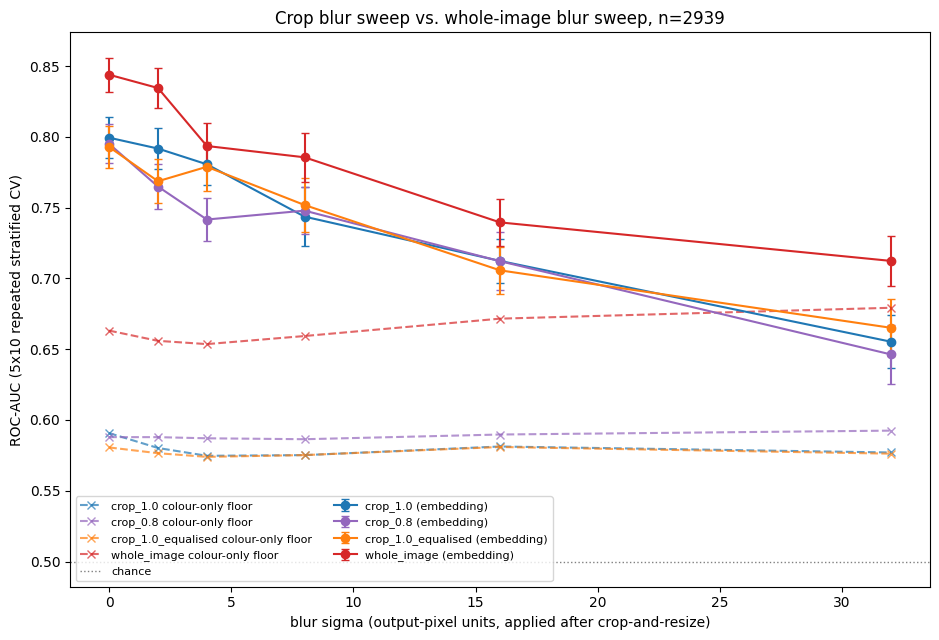

In [20]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))

arm_colors = {
    "crop_1.0": "tab:blue",
    "crop_0.8": "tab:purple",
    "crop_1.0_equalised": "tab:orange",
    "whole_image": "tab:red",
}
for arm in cfg.arm_names:
    emb = summary.loc[summary["arm"] == arm].sort_values("sigma")
    col = colour_summary.loc[colour_summary["arm"] == arm].sort_values("sigma")
    ax.errorbar(
        emb["sigma"], emb["roc_auc_mean"], yerr=emb["roc_auc_sd"],
        marker="o", capsize=3, color=arm_colors[arm], label=f"{arm} (embedding)",
    )
    ax.plot(
        col["sigma"], col["roc_auc_mean"], linestyle="--", marker="x",
        color=arm_colors[arm], alpha=0.7, label=f"{arm} colour-only floor",
    )

ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, label="chance")
ax.set_xlabel("blur sigma (output-pixel units, applied after crop-and-resize)")
ax.set_ylabel("ROC-AUC (5x10 repeated stratified CV)")
ax.set_title(f"Crop blur sweep vs. whole-image blur sweep, n={len(manifest)}")
ax.legend(fontsize=8, ncol=2, loc="lower left")
fig.tight_layout()
plt.show()

## 10. How to read it

| Crop blur curve | Reading |
|---|---|
| Falls to its colour floor as fast as the whole-image curve did | The signal is surface texture. Texture is a property of the photograph, not the child — consistent with the studio-versus-snapshot difference seen in the original audit |
| Holds well above its colour floor at sigma where whole-image performance had collapsed | Coarse facial structure carries signal that survives loss of texture. The strongest evidence yet for the facial hypothesis |
| Collapses immediately, below the colour floor | Check the crops visually before interpreting — likely a pipeline fault |

**What actually happened, in numbers.** At sigma=0, `crop_1.0` scores
0.799 against its own colour floor of 0.591 — a gap of 0.209 AUC. By
sigma=32 (the top of this sweep), that gap has shrunk to 0.078 — **62% of
the headroom above colour is gone.** `crop_0.8` loses 74% of its headroom
over the same range (0.207 -> 0.054); `crop_1.0_equalised` loses 58%
(0.212 -> 0.089). All three crop arms are, primarily, converging on their
colour floor exactly as the first row predicts. For comparison,
`whole_image`, re-run on this notebook's same reduced row set, loses 82%
of its headroom over the identical sigma range (0.181 -> 0.033) — the
whole-image curve collapses toward its floor slightly *faster and more
completely* than any of the three crop curves do, not slower.

**The residual is real but modest, and resampling is not what's causing
it.** All three crop arms retain a somewhat larger fraction of their
original headroom at sigma=32 (26-42%) than `whole_image` does (18%) —
a real gap, not noise (fold-level sd on every point here is ~0.015-0.025
AUC, well under the 0.02-0.06 AUC differences involved). But it holds up
almost identically whether the crop is resolution-equalised or not
(`crop_1.0`: 37.5% of headroom remains; `crop_1.0_equalised`: 41.9%
remains) — so the systematic, class-correlated upsampling factor from
Part 2 (Part 5's stated confound) is **not** what is producing this
residual: an artefact of that kind would have shrunk or vanished under
equalisation, and it does neither.

**Reading:** predominantly the first row, with a small, second-row-shaped
exception this sweep cannot fully resolve. The large majority of each
crop arm's advantage over colour-only classification behaves exactly like
`blurred_images`'s whole-image result: it is surface texture, gone within
a handful of sigma-doublings, consistent with a property of the
photograph rather than the child. But a modest residual — roughly 0.05 to
0.09 AUC of headroom, a quarter to two-fifths of what each crop arm
started with — persists longer under blur inside the crop than the
identical-sigma whole-image curve's residual does, and that difference
survives the one confound (differential upsampling) this notebook could
rule out. This sweep stops at sigma=32, the ceiling set for this
experiment (`blurred_images` went to 64); whether that residual is
genuine coarse facial structure or would itself vanish with one or two
more sigma-doublings is not settled by the six points measured here, and
is the natural next step if it is worth resolving.

The original corpus audit found the non-autistic images were smoothed,
soft-focus studio portraits, and that the six least-sharp images in the
whole corpus were all non-autistic — the first row was the more likely
outcome going in, and this sweep mostly confirms it rather than
overturning it. That is not a disappointing result: it means most of the
signal `intact_images` and `blurred_images` picked up is a property of
*how the photograph was taken*, not of the face in it. The unresolved
residual above is the one thread this notebook leaves open, not a
reversal of that reading.

**Known limitation, carried over from every prior notebook, not fixed
here.** The dataset's near-duplicate image pairs (11 pairs, 5 crossing
published-split boundaries) are pooled into cross-validation exactly as
in every arm above — a duplicate can land on both sides of a fold, mildly
inflating every point on every curve by roughly the same amount. Because
every arm and sigma here reuses the same manifest, fold assignment and
seed, this affects every curve's *height* a little, not its *shape*.
`repeated_stratified_cv`'s `groups=` parameter remains the seam where the
fix goes once perceptual-hash grouping exists.